#  Telco Customer Churn — Model Interpretation with SHAP
**Notebook:** 05_interpretation.ipynb  
**Model:** XGBoost Tuned (best model from notebook 03)  
**Goal:** Understand *why* the model predicts churn using SHAP values — global, local, and business insights.

## 1.  Install & Import

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
print('SHAP installed ')

SHAP installed 


In [2]:
import warnings
import os
import joblib
import json

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import matplotlib.ticker    as mtick
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
shap.initjs()                     # enable JS widgets in Jupyter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'    : 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family'   : 'DejaVu Sans',
})

PROCESSED   = '../data/processed/'
MODELS_DIR  = '../models/'
OUTPUT_DIR  = '../reports/shap/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'SHAP version    : {shap.__version__}')
print(f'XGBoost version : {xgb.__version__}')

SHAP version    : 0.52.0
XGBoost version : 3.2.0


## 2.  Load Model & Data

In [3]:
# ── Data ─────────────────────────────────────────────────────────────────────
X_train = pd.read_csv(PROCESSED + 'X_train.csv')
X_test  = pd.read_csv(PROCESSED + 'X_test.csv')
y_train = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()

# ── Model ─────────────────────────────────────────────────────────────────────
model = joblib.load(MODELS_DIR + 'xgb_tuned_final.pkl')

# ── Threshold ─────────────────────────────────────────────────────────────────
with open(MODELS_DIR + 'best_threshold.txt') as f:
    threshold = float(f.read().strip())

# ── Quick sanity check ────────────────────────────────────────────────────────
prob_test = model.predict_proba(X_test)[:, 1]
print(f'Model loaded — Test AUC-ROC : {roc_auc_score(y_test, prob_test):.4f}')
print(f'Decision threshold          : {threshold}')
print(f'X_test shape                : {X_test.shape}')

Model loaded — Test AUC-ROC : 0.8487
Decision threshold          : 0.6
X_test shape                : (1409, 45)


## 3.  TreeExplainer — Compute SHAP Values
`shap.TreeExplainer` is the exact, fast explainer for tree-based models.
It decomposes each prediction into additive feature contributions with **no approximation**.

In [4]:
print('Building TreeExplainer …')
explainer = shap.TreeExplainer(
    model,
    data                   = shap.sample(X_train, 200, random_state=42),  # background
    feature_perturbation   = 'interventional',   # marginalise out features properly
    model_output           = 'probability'        # SHAP values in probability space
)

print('Computing SHAP values on test set …')
explanation = explainer(X_test)     # → shap.Explanation object
shap_values = explanation.values    # shape (n_test, n_features)
base_value  = explanation.base_values[0]

print(f'SHAP values shape : {shap_values.shape}')
print(f'Base value (E[f(x)]) : {base_value:.4f}  '
      f'(= mean predicted churn probability ≈ {y_test.mean():.4f})')

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Building TreeExplainer …
Computing SHAP values on test set …


 97%|=================== | 1368/1409 [00:26<00:00]       

SHAP values shape : (1409, 45)
Base value (E[f(x)]) : 0.4344  (= mean predicted churn probability ≈ 0.2654)


In [5]:
# ── SHAP values DataFrame for downstream analysis ─────────────────────────────
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

# Mean absolute SHAP per feature
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print('\nTop-10 features by mean |SHAP|:')
print(mean_abs_shap.head(10).to_string())


Top-10 features by mean |SHAP|:
Contract_Month-to-month           0.081266
ChargeRatio                       0.044775
InternetService_Fiber optic       0.041258
OnlineSecurity_No                 0.036657
tenure                            0.032551
Contract_Two year                 0.030874
TechSupport_No                    0.027455
MonthlyCharges                    0.026376
PaymentMethod_Electronic check    0.025647
PaperlessBilling                  0.016564


## 4.  SHAP Summary Plot (Beeswarm)
Each dot = one customer on the test set.  
**X-axis**: SHAP value (impact on churn probability).  
**Colour**: feature value (red = high, blue = low).  
**Y-axis**: features ranked by mean |SHAP|.

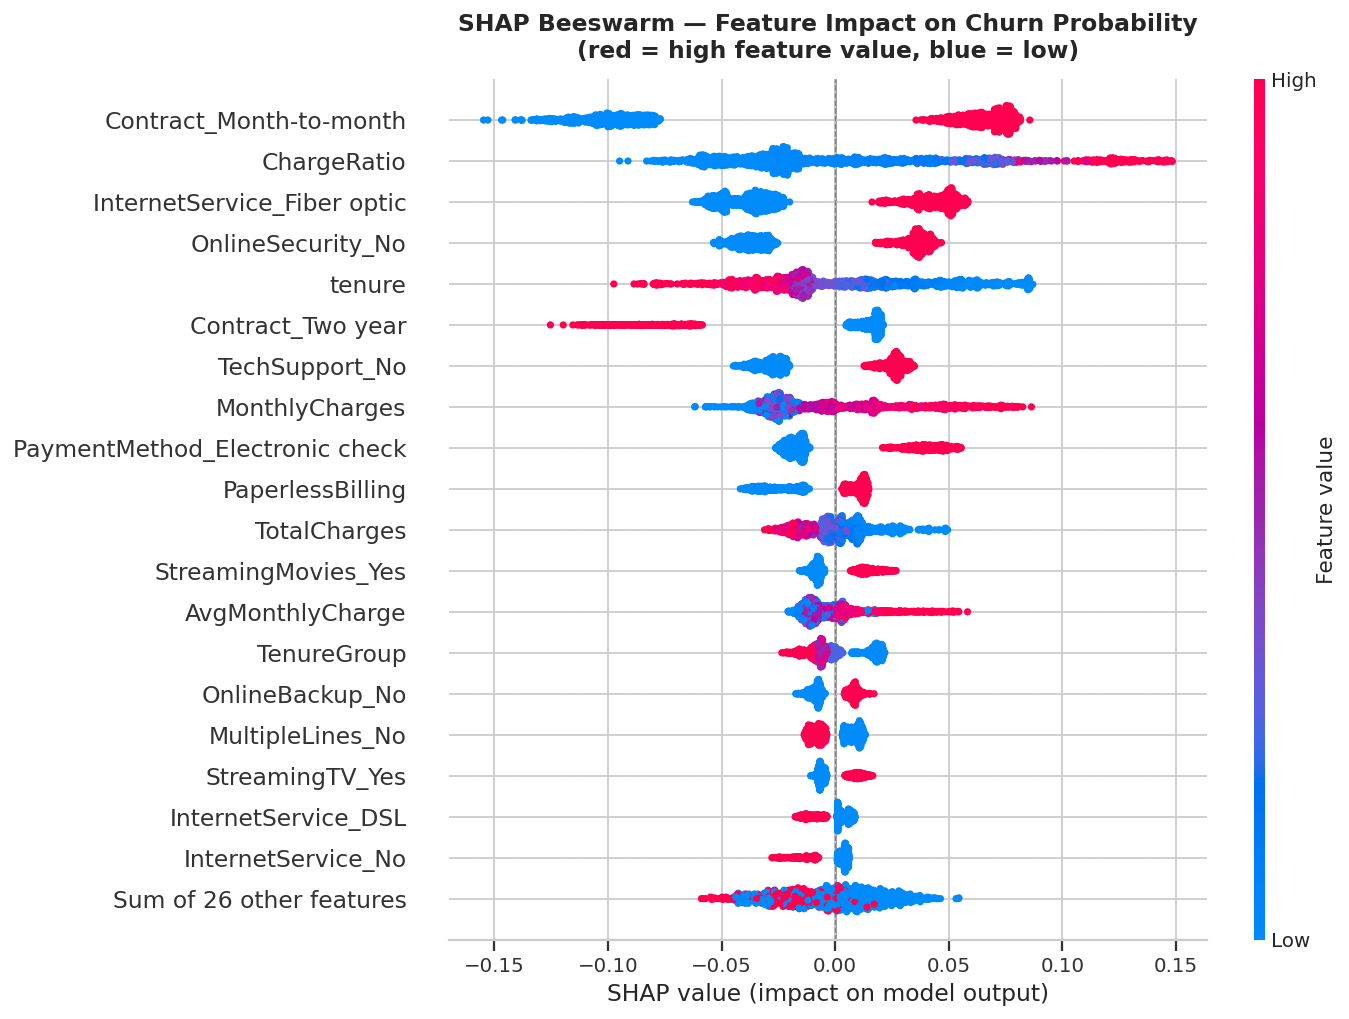

In [7]:
fig = plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    explanation,
    max_display=20,
    show=False,
    plot_size=None
)

plt.title(
    'SHAP Beeswarm — Feature Impact on Churn Probability\n'
    '(red = high feature value, blue = low)',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.axvline(0, color='grey', lw=0.8, linestyle='--')

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR + 'shap_beeswarm.png',
    bbox_inches='tight'
)

plt.show()

## 5.  SHAP Feature Importance (Bar Plot)
Mean absolute SHAP value per feature — a model-agnostic, consistent importance metric  
that reflects *actual impact on predictions* (unlike impurity-based importance).

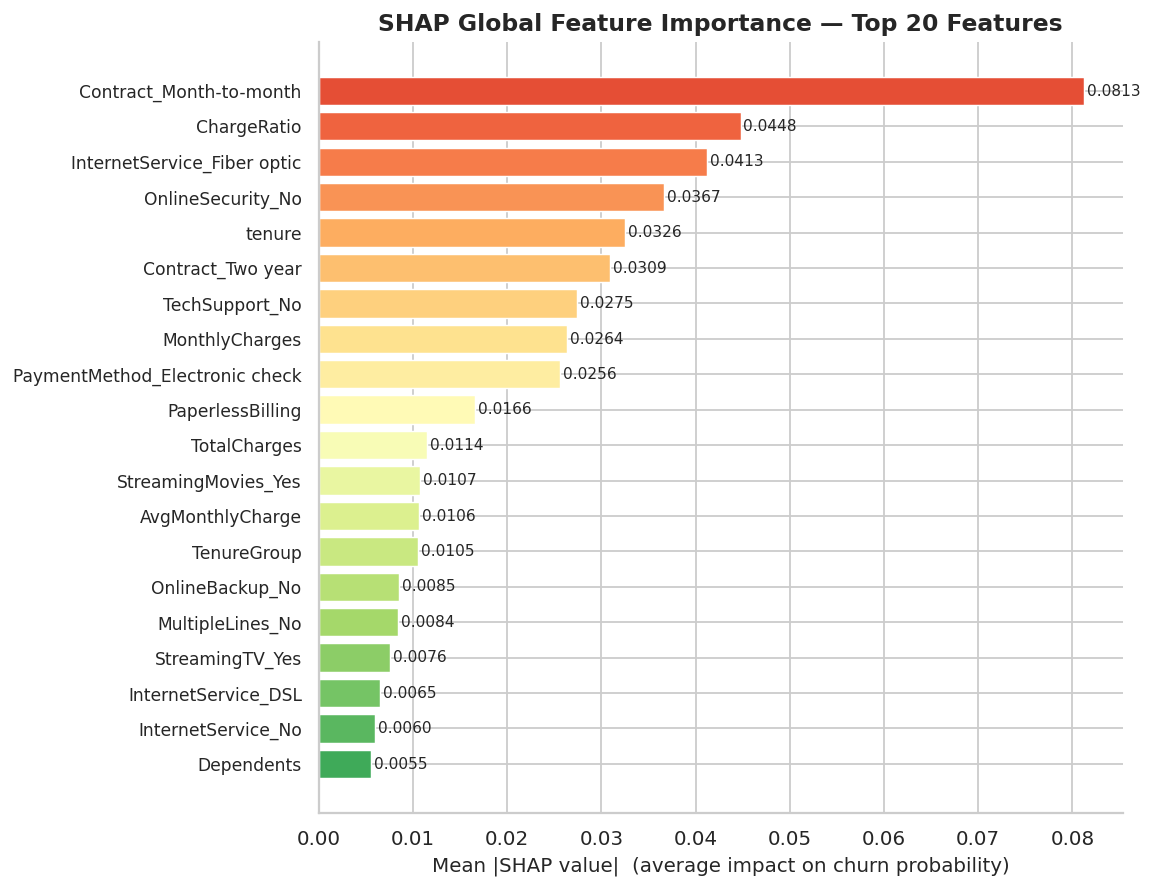

Saved: shap_bar_importance.png


In [8]:
top_n = 20
top_features  = mean_abs_shap.head(top_n)
colors_bar    = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, top_n))

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    top_features.index[::-1],
    top_features.values[::-1],
    color   = colors_bar,
    edgecolor = 'white',
    linewidth = 0.8
)
for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Mean |SHAP value|  (average impact on churn probability)', fontsize=11)
ax.set_title(f'SHAP Global Feature Importance — Top {top_n} Features',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='y', labelsize=9.5)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'shap_bar_importance.png', bbox_inches='tight')
plt.show()
print('Saved: shap_bar_importance.png')

## 6.  SHAP Dependence Plots
Each scatter plot shows how one feature's value maps to its SHAP contribution,  
coloured by a second feature to reveal **interaction effects**.

In [9]:
# ── Helper: flexible dependence plot ──────────────────────────────────────────
def dependence_plot(feature, interaction_feature=None, ax=None, title_suffix=''):
    """SHAP dependence plot with optional interaction colouring."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    feat_vals  = X_test[feature].values
    shap_vals_f = shap_df[feature].values

    if interaction_feature and interaction_feature in X_test.columns:
        int_vals = X_test[interaction_feature].values
        scatter  = ax.scatter(feat_vals, shap_vals_f,
                              c=int_vals, cmap='coolwarm',
                              alpha=0.55, s=18, linewidths=0)
        plt.colorbar(scatter, ax=ax, label=interaction_feature)
    else:
        ax.scatter(feat_vals, shap_vals_f,
                   c=shap_vals_f, cmap='RdBu_r',
                   alpha=0.55, s=18, linewidths=0)

    ax.axhline(0, color='grey', lw=0.8, linestyle='--')

    # LOWESS smoothing line
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        smooth = lowess(shap_vals_f, feat_vals, frac=0.4)
        sort_idx = np.argsort(smooth[:, 0])
        ax.plot(smooth[sort_idx, 0], smooth[sort_idx, 1],
                color='black', lw=2, label='LOWESS trend')
        ax.legend(fontsize=8)
    except ImportError:
        pass

    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel(f'SHAP value for {feature}', fontsize=10)
    ax.set_title(f'Dependence: {feature}{title_suffix}', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    return ax

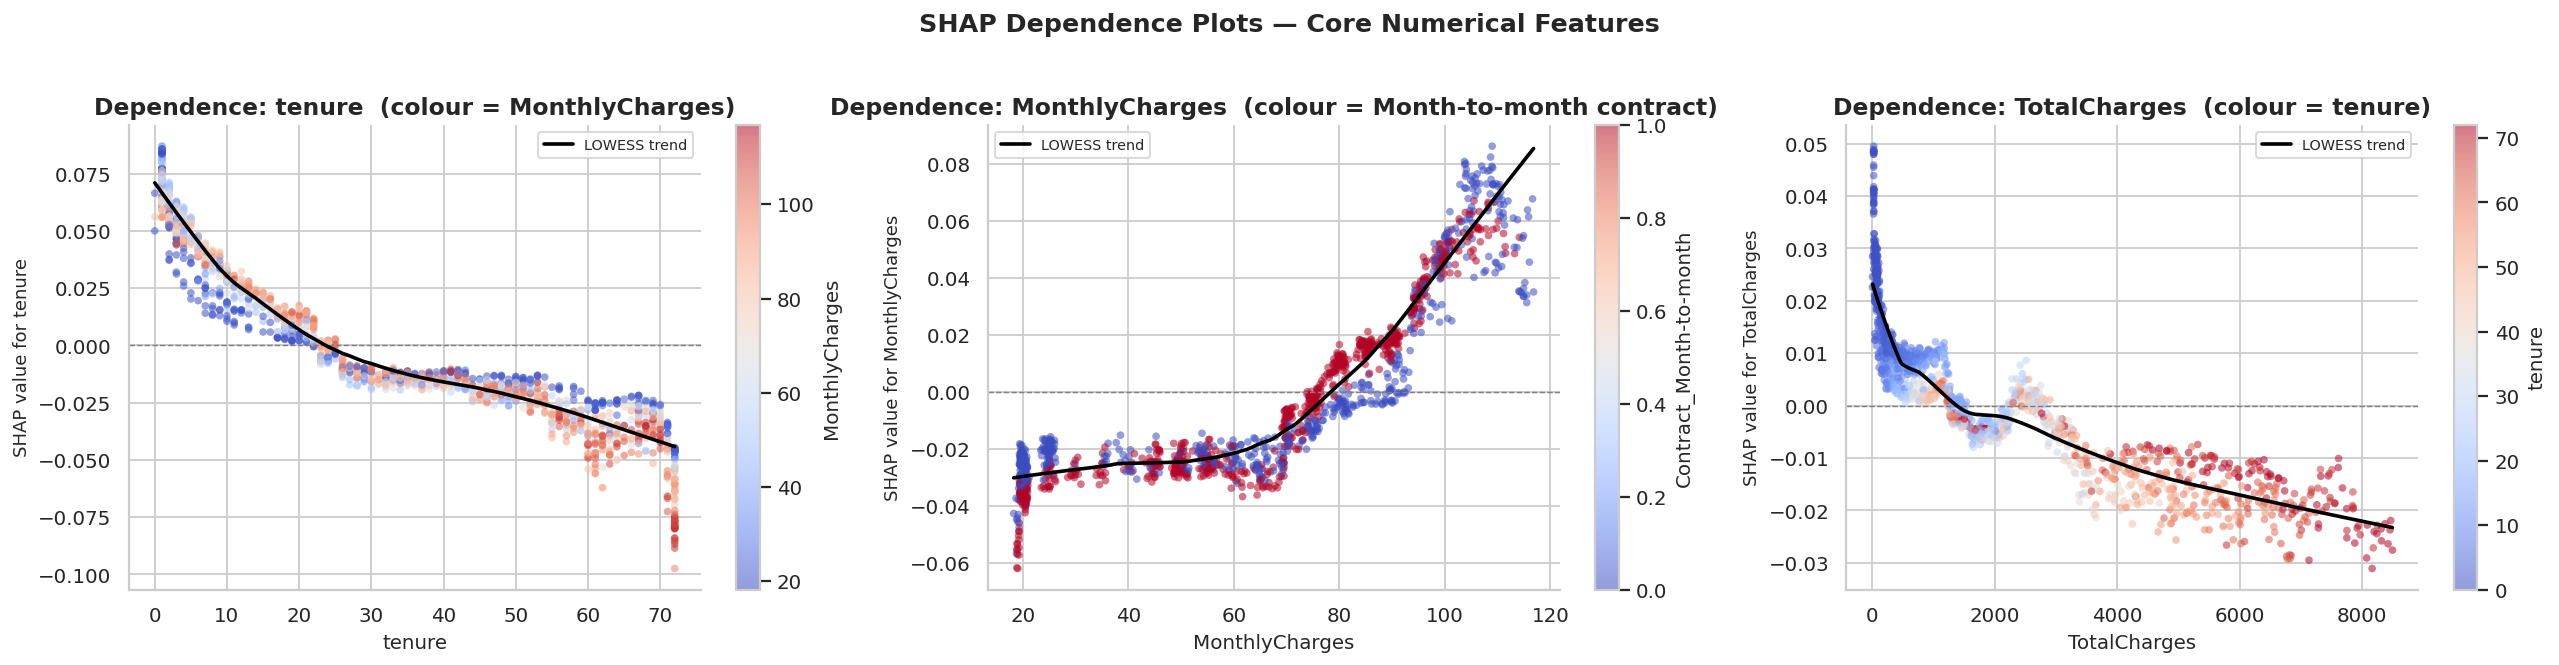

Saved: shap_dependence_numerical.png


In [10]:
# ── 6.1  tenure — coloured by MonthlyCharges ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

dependence_plot('tenure', interaction_feature='MonthlyCharges',
                ax=axes[0], title_suffix='  (colour = MonthlyCharges)')

# ── 6.2  MonthlyCharges — coloured by Contract_Month-to-month ────────────────
int_col = next((c for c in X_test.columns if 'Month-to-month' in c), None)
dependence_plot('MonthlyCharges', interaction_feature=int_col,
                ax=axes[1],
                title_suffix='  (colour = Month-to-month contract)')

# ── 6.3  TotalCharges ────────────────────────────────────────────────────────
dependence_plot('TotalCharges', interaction_feature='tenure',
                ax=axes[2], title_suffix='  (colour = tenure)')

plt.suptitle('SHAP Dependence Plots — Core Numerical Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'shap_dependence_numerical.png', bbox_inches='tight')
plt.show()
print('Saved: shap_dependence_numerical.png')

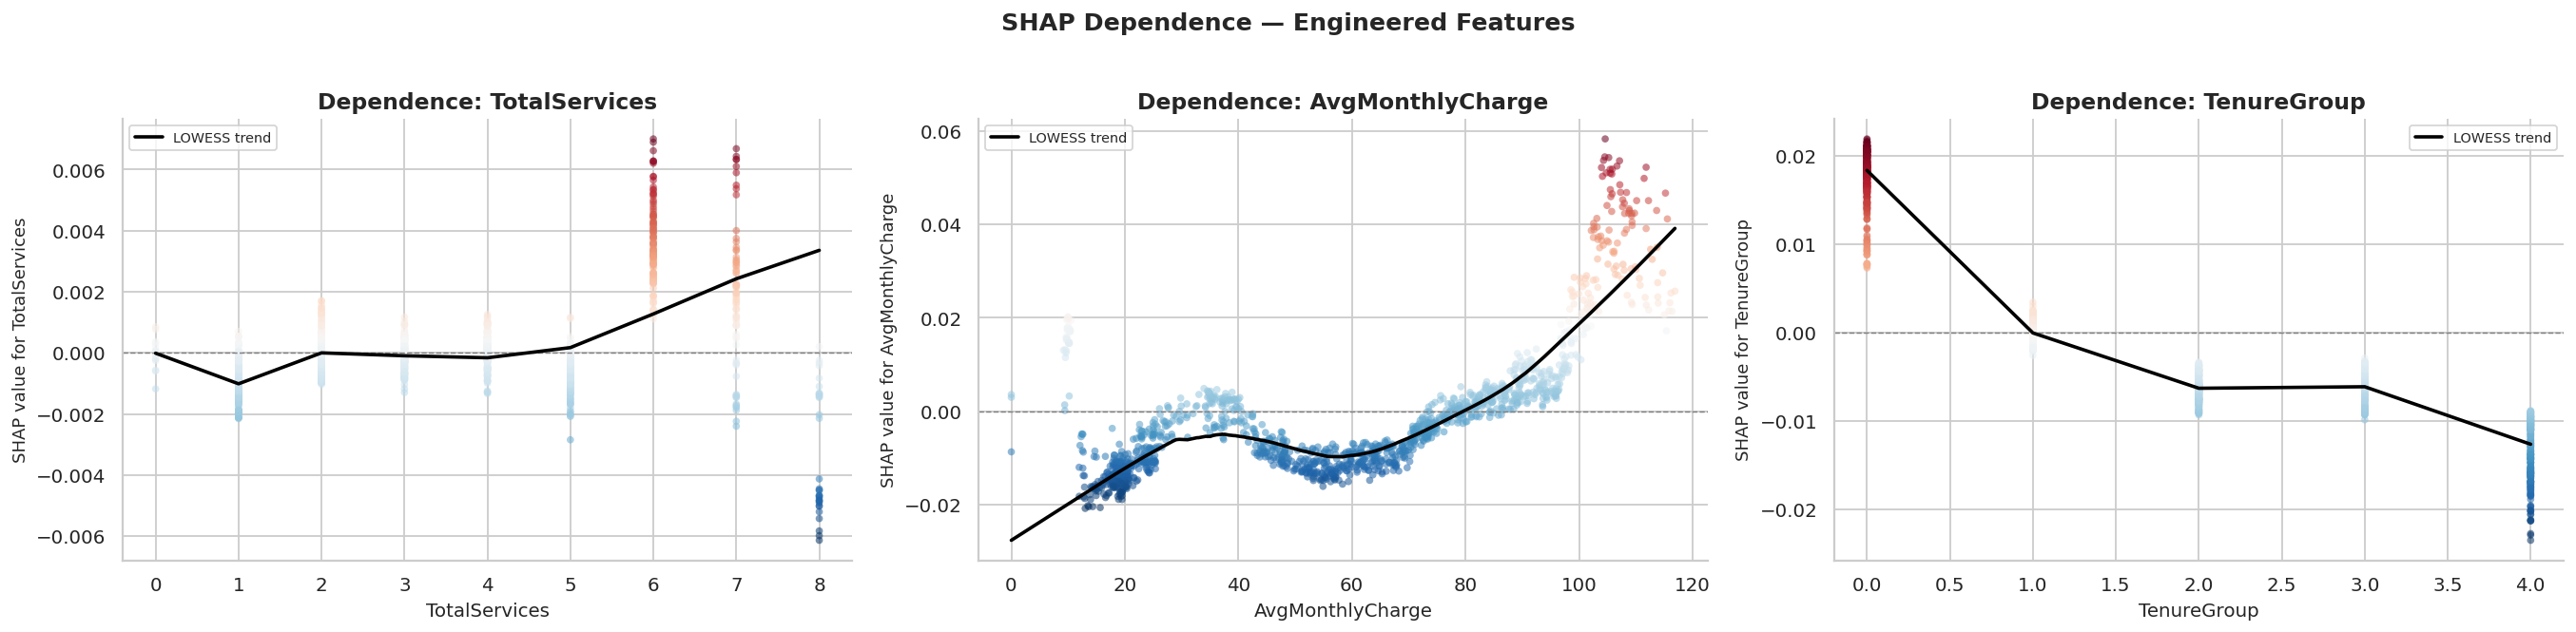

Saved: shap_dependence_engineered.png


In [11]:
# ── 6.4  Engineered features: TotalServices, AvgMonthlyCharge, TenureGroup ───
eng_features = ['TotalServices', 'AvgMonthlyCharge', 'TenureGroup']
eng_features = [f for f in eng_features if f in X_test.columns]

if eng_features:
    fig, axes = plt.subplots(1, len(eng_features),
                             figsize=(7 * len(eng_features), 5))
    if len(eng_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, eng_features):
        dependence_plot(feat, ax=ax)
    plt.suptitle('SHAP Dependence — Engineered Features',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR + 'shap_dependence_engineered.png', bbox_inches='tight')
    plt.show()
    print('Saved: shap_dependence_engineered.png')

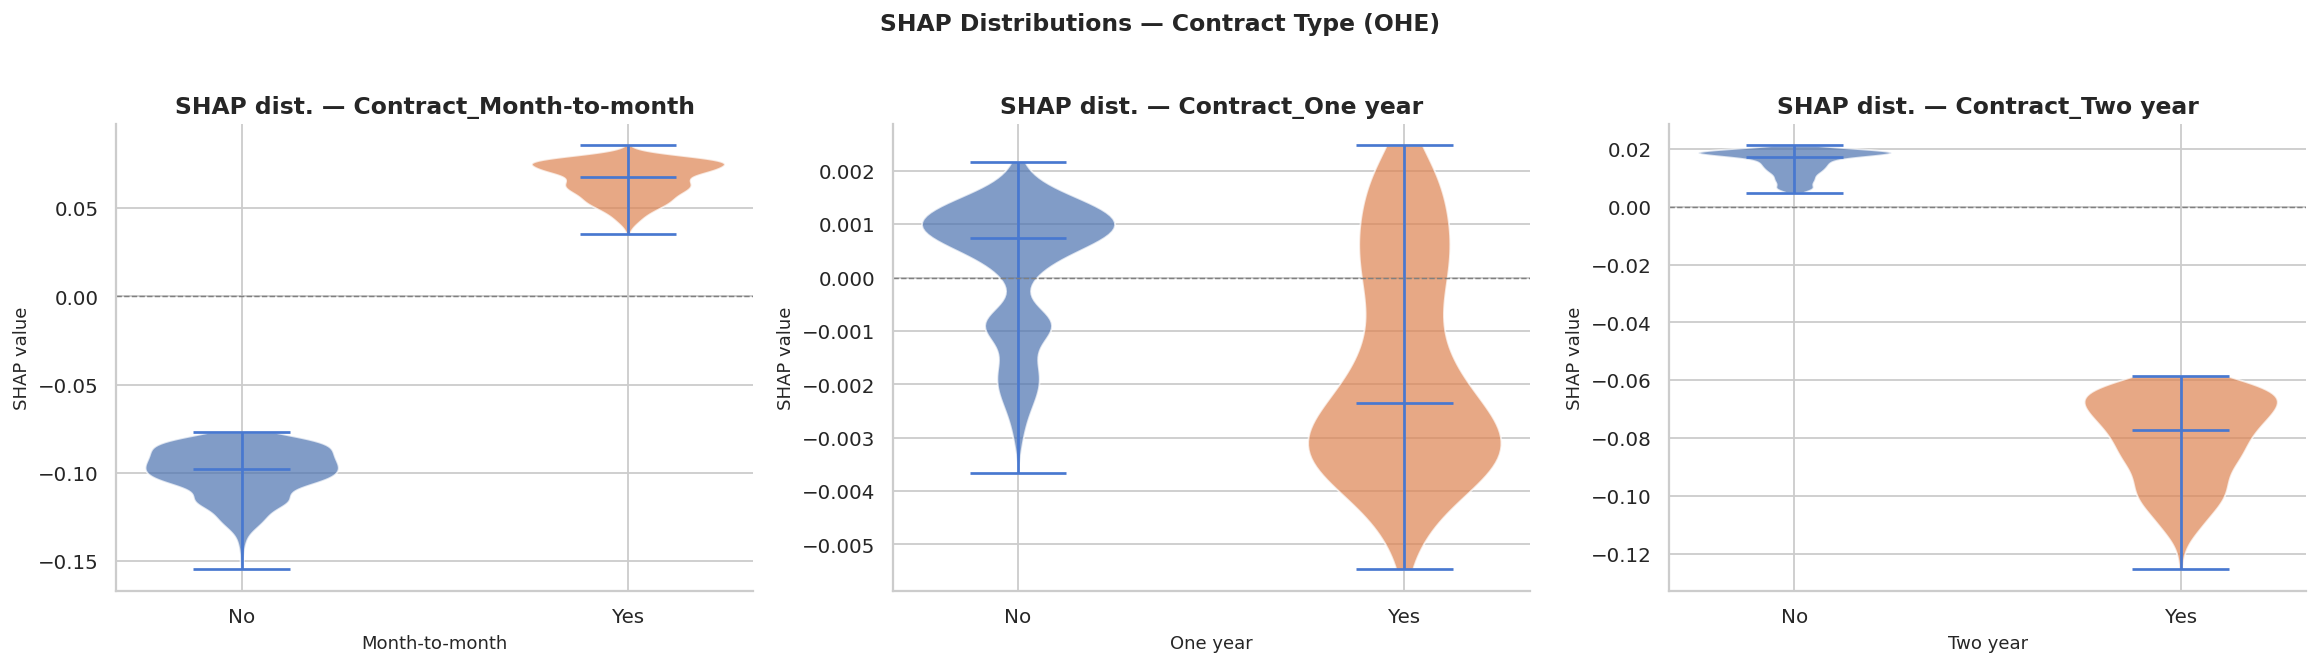

Saved: shap_dependence_contract.png


In [12]:
# ── 6.5  Contract type OHE columns ───────────────────────────────────────────
contract_cols = [c for c in X_test.columns if c.startswith('Contract_')]

if contract_cols:
    fig, axes = plt.subplots(1, len(contract_cols),
                             figsize=(6 * len(contract_cols), 5))
    if len(contract_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, contract_cols):
        # Violin: SHAP dist per binary category
        data_0 = shap_df.loc[X_test[col] == 0, col].values
        data_1 = shap_df.loc[X_test[col] == 1, col].values
        vp = ax.violinplot([data_0, data_1],
                           positions=[0, 1], showmedians=True)
        for pc, color in zip(vp['bodies'], ['#4C72B0', '#DD8452']):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No', 'Yes'])
        ax.set_xlabel(col.replace('Contract_', ''), fontsize=10)
        ax.set_ylabel('SHAP value', fontsize=10)
        ax.set_title(f'SHAP dist. — {col}', fontweight='bold')
        ax.axhline(0, color='grey', lw=0.8, linestyle='--')
        ax.spines[['top','right']].set_visible(False)

    plt.suptitle('SHAP Distributions — Contract Type (OHE)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR + 'shap_dependence_contract.png', bbox_inches='tight')
    plt.show()
    print('Saved: shap_dependence_contract.png')

## 7.  Waterfall (Force) Plots — Individual Customers
Waterfall plots decompose a single prediction into its feature contributions,  
starting from the base value (average prediction) and showing each feature's push/pull.

In [13]:
# ── Select representative individual customers ────────────────────────────────
def pick_customer(label, prob_range, y_true_val=None):
    """Return index of first customer matching probability range and optional true label."""
    mask = (prob_test >= prob_range[0]) & (prob_test <= prob_range[1])
    if y_true_val is not None:
        mask &= (y_test.values == y_true_val)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        idxs = np.where((prob_test >= prob_range[0]) & (prob_test <= prob_range[1]))[0]
    idx = idxs[0] if len(idxs) > 0 else 0
    print(f'  {label:<30}: row {idx:4d}  '
          f'P(churn)={prob_test[idx]:.3f}  '
          f'true={int(y_test.values[idx])}')
    return idx

print('Selected customers:')
customers = {
    'High-risk churner  (TP)' : pick_customer('High-risk churner (TP)',   (0.75, 1.0),  y_true_val=1),
    'Borderline customer'     : pick_customer('Borderline',               (0.45, 0.55)),
    'Low-risk loyal (TN)'     : pick_customer('Low-risk loyal (TN)',      (0.0,  0.15), y_true_val=0),
    'False positive (FP)'     : pick_customer('False positive (FP)',      (0.6,  1.0),  y_true_val=0),
    'False negative (FN)'     : pick_customer('False negative (FN)',      (0.0,  0.4),  y_true_val=1),
}

Selected customers:
  High-risk churner (TP)        : row   13  P(churn)=0.827  true=1
  Borderline                    : row   10  P(churn)=0.525  true=0
  Low-risk loyal (TN)           : row    0  P(churn)=0.086  true=0
  False positive (FP)           : row    1  P(churn)=0.850  true=0
  False negative (FN)           : row   39  P(churn)=0.364  true=1


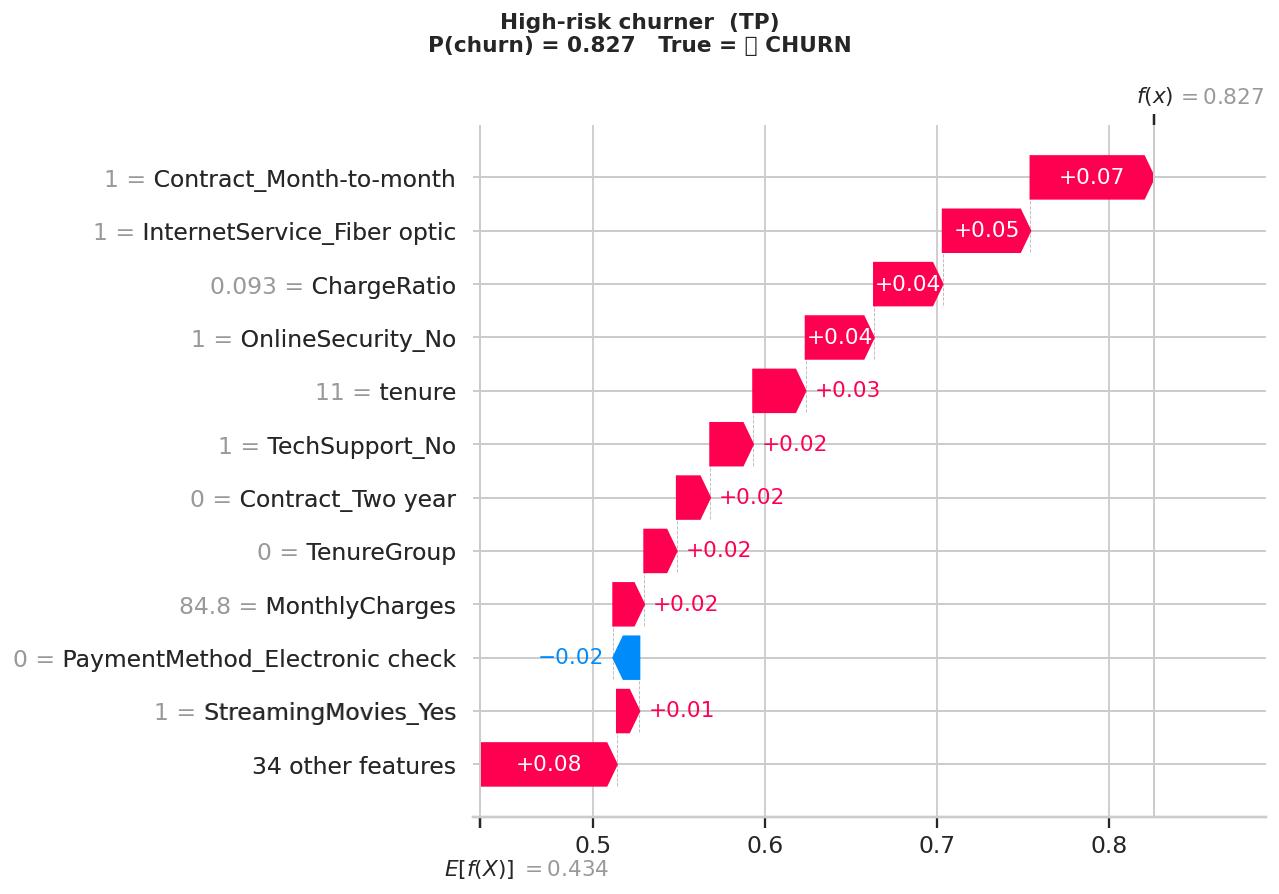

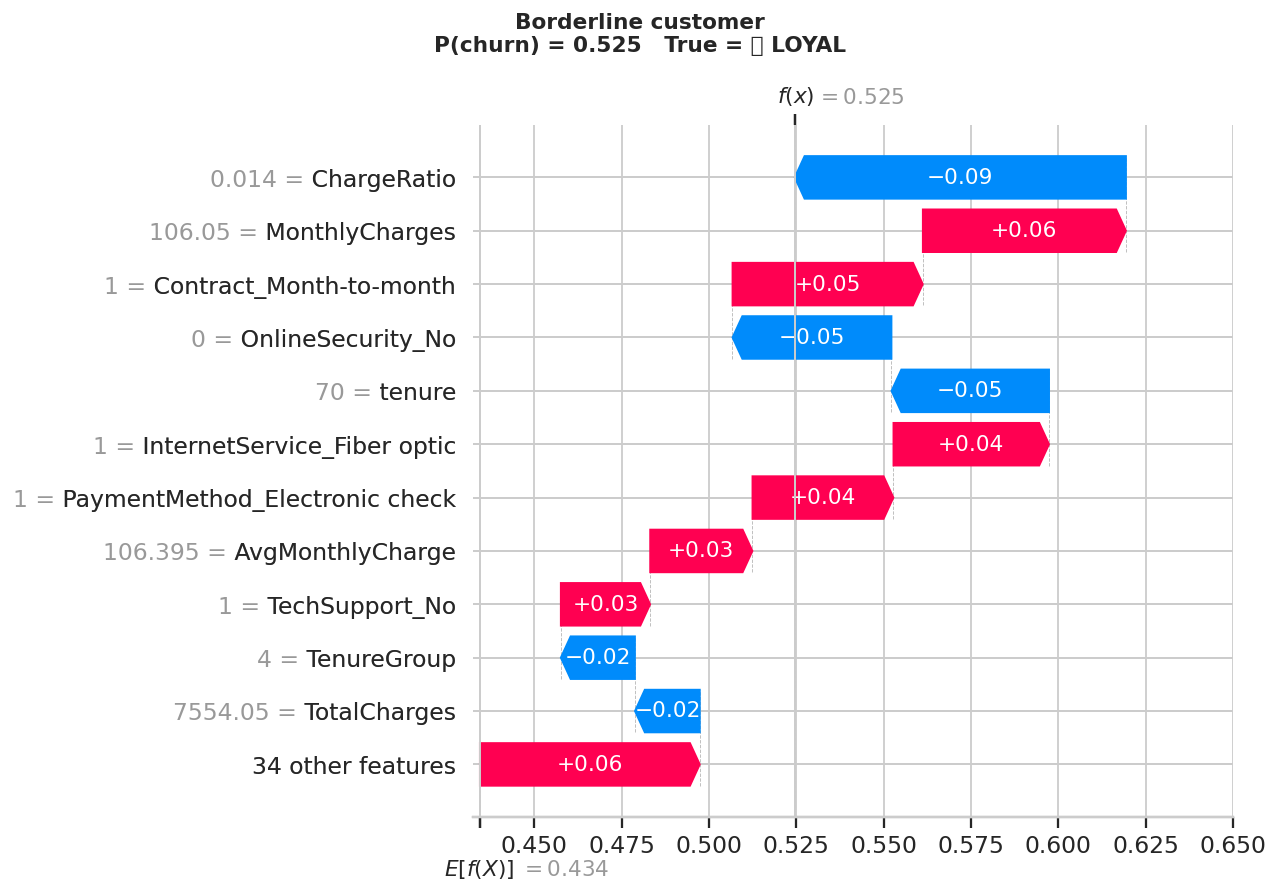

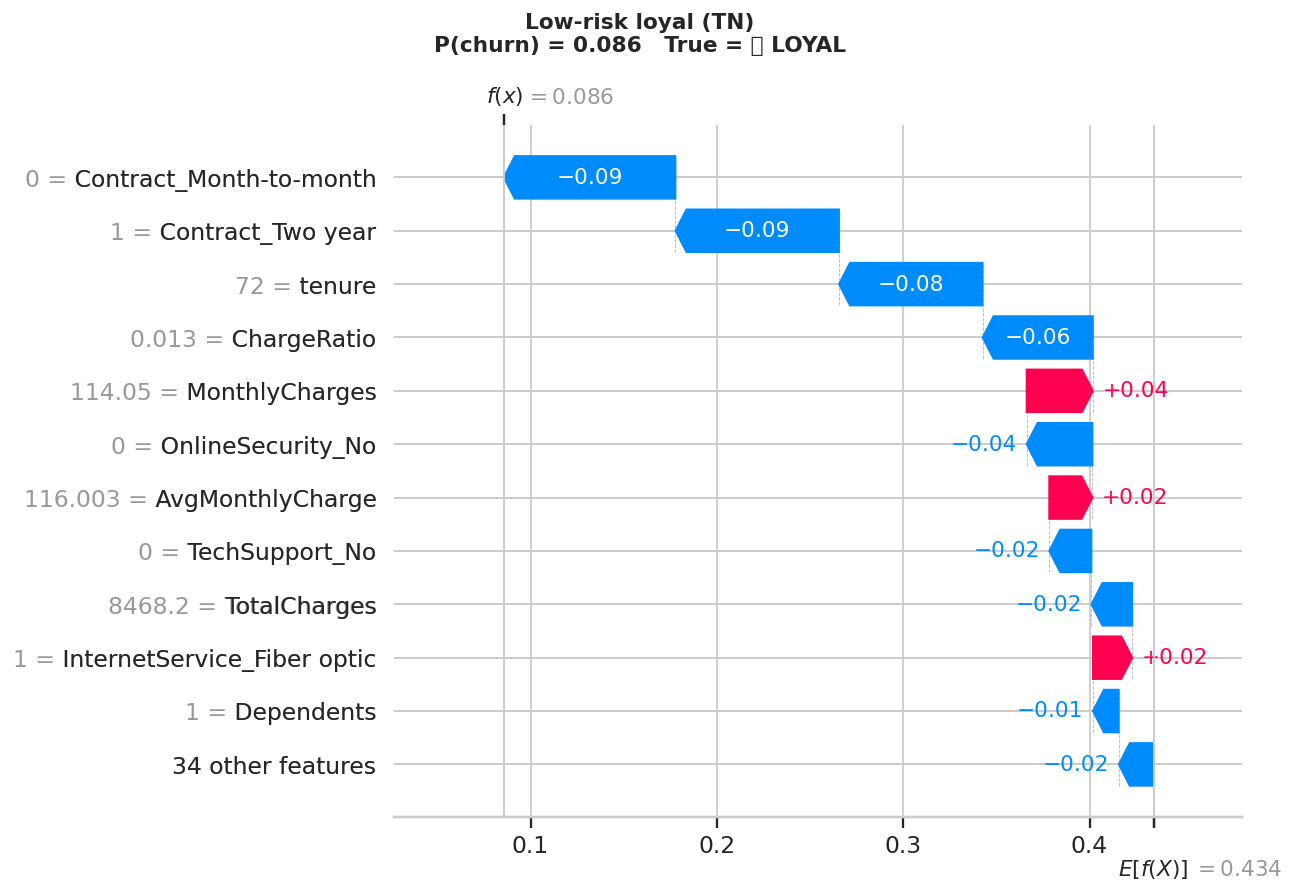

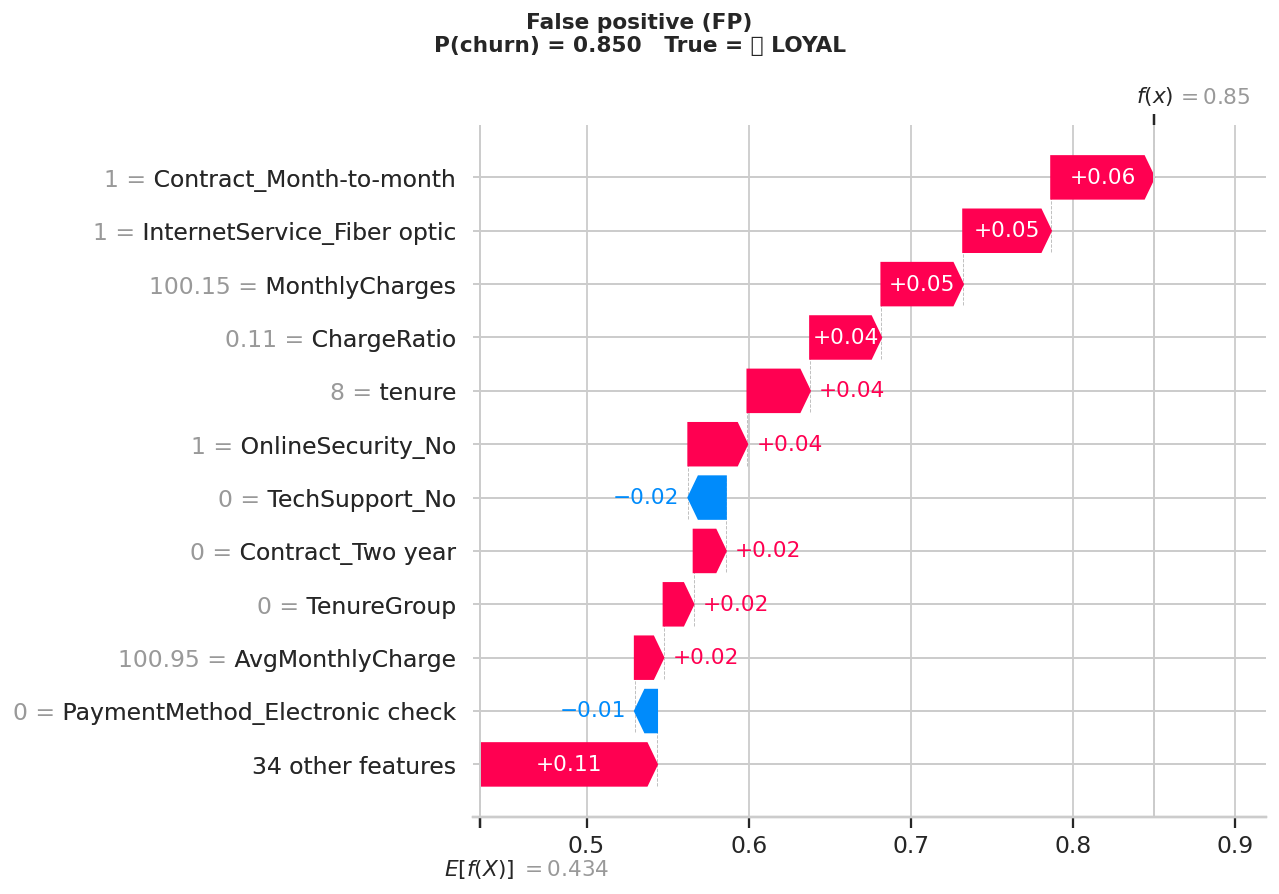

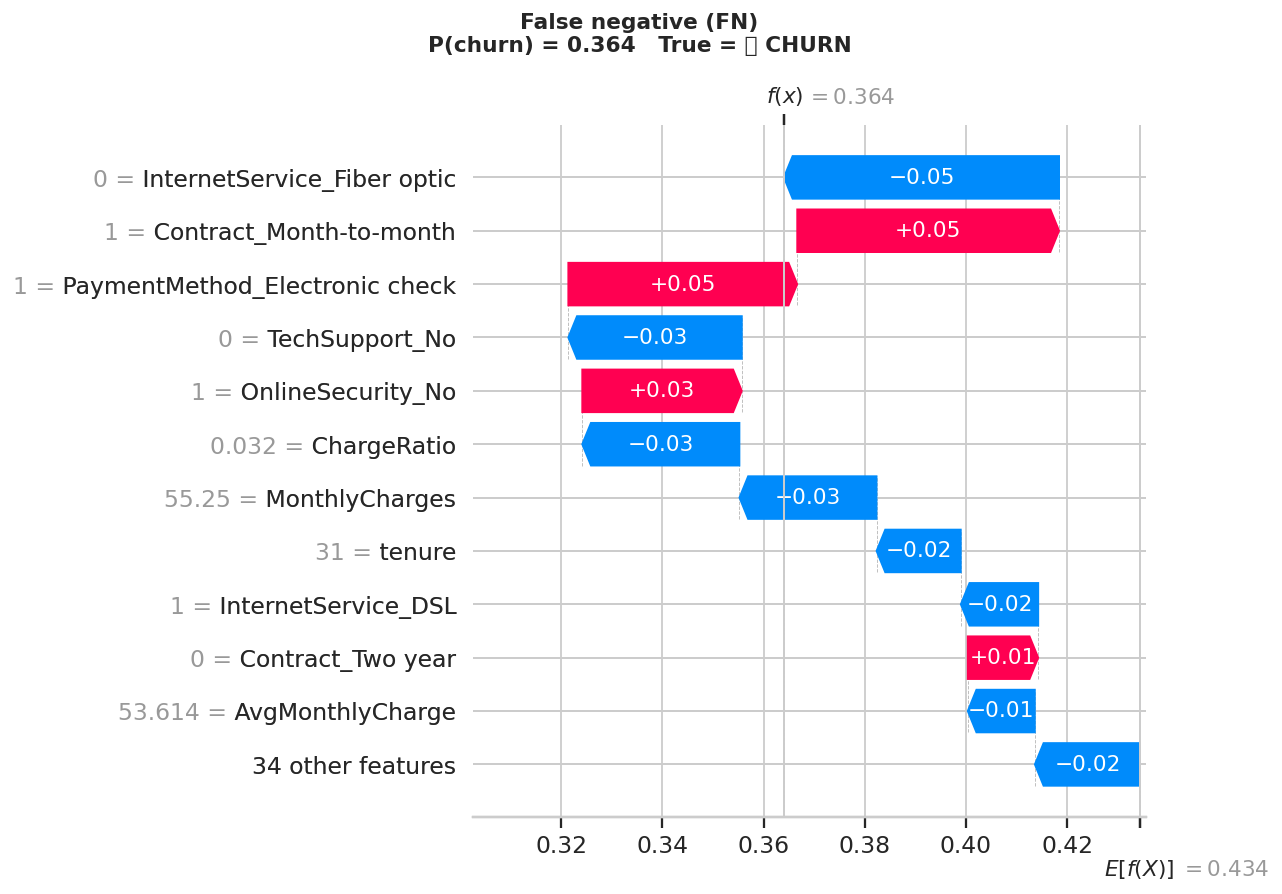

Saved 5 waterfall plots to: ../reports/shap/waterfalls


In [23]:
# ── SHAP Waterfall Plots — Individual Customer Explanations ────────────────

import os

waterfall_dir = os.path.join(OUTPUT_DIR, "waterfalls")
os.makedirs(waterfall_dir, exist_ok=True)

for label, idx in customers.items():

    churn_flag = "🔴 CHURN" if y_test.iloc[idx] == 1 else "🟢 LOYAL"

    shap.plots.waterfall(
        explanation[idx],
        max_display=12,
        show=False
    )

    fig = plt.gcf()

    fig.set_size_inches(10, 7)

    plt.suptitle(
        f"{label}\n"
        f"P(churn) = {prob_test[idx]:.3f}   True = {churn_flag}",
        fontsize=12,
        fontweight="bold",
        y=0.98
    )

    plt.tight_layout()

    fig.savefig(
        os.path.join(waterfall_dir, f"{label}_waterfall.png"),
        bbox_inches="tight",
        dpi=300
    )

    plt.show()
    plt.close(fig)

print(f"Saved {len(customers)} waterfall plots to: {waterfall_dir}")

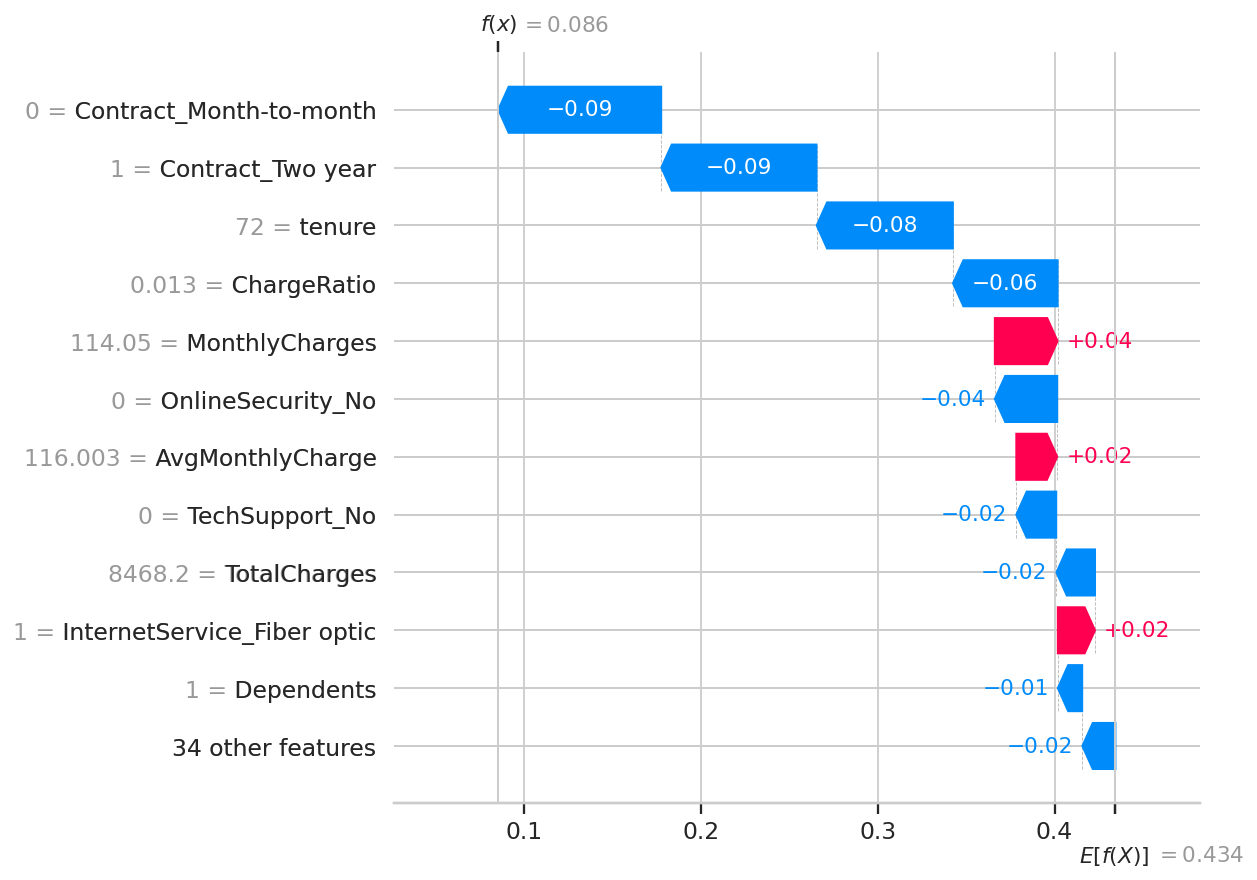

In [22]:
shap.plots.waterfall(
    explanation[0],
    max_display=12
)

In [24]:
# ── Interactive Force Plot (HTML — works in Jupyter) ─────────────────────────
# Shows probability scale with red/blue feature contributions
high_risk_idx = customers['High-risk churner  (TP)']

print(f'Interactive Force Plot — High-Risk Churner (row {high_risk_idx})')
print(f'P(churn) = {prob_test[high_risk_idx]:.4f}')

shap.plots.force(
    explanation[high_risk_idx],
    matplotlib = False,    # renders as HTML widget in Jupyter
    figsize    = (20, 4)
)

Interactive Force Plot — High-Risk Churner (row 13)
P(churn) = 0.8265


In [25]:
# ── Stacked Force Plot: multi-customer view (sorted by prediction) ────────────
# Sample 300 test customers for readability
sample_idx = np.argsort(prob_test)      # sort by P(churn) low → high
sample_idx = np.concatenate([           # keep 150 low-risk + 150 high-risk
    sample_idx[:150], sample_idx[-150:]
])

print('Multi-sample stacked force plot (300 customers):')
shap.plots.force(
    explanation[sample_idx],
    matplotlib = False
)

Multi-sample stacked force plot (300 customers):


## 8.  SHAP Heatmap — All Test Customers
Rows = features (top-20), columns = test customers sorted by predicted churn probability.  
Reveals **cohort patterns** — which customer segments share similar risk drivers.

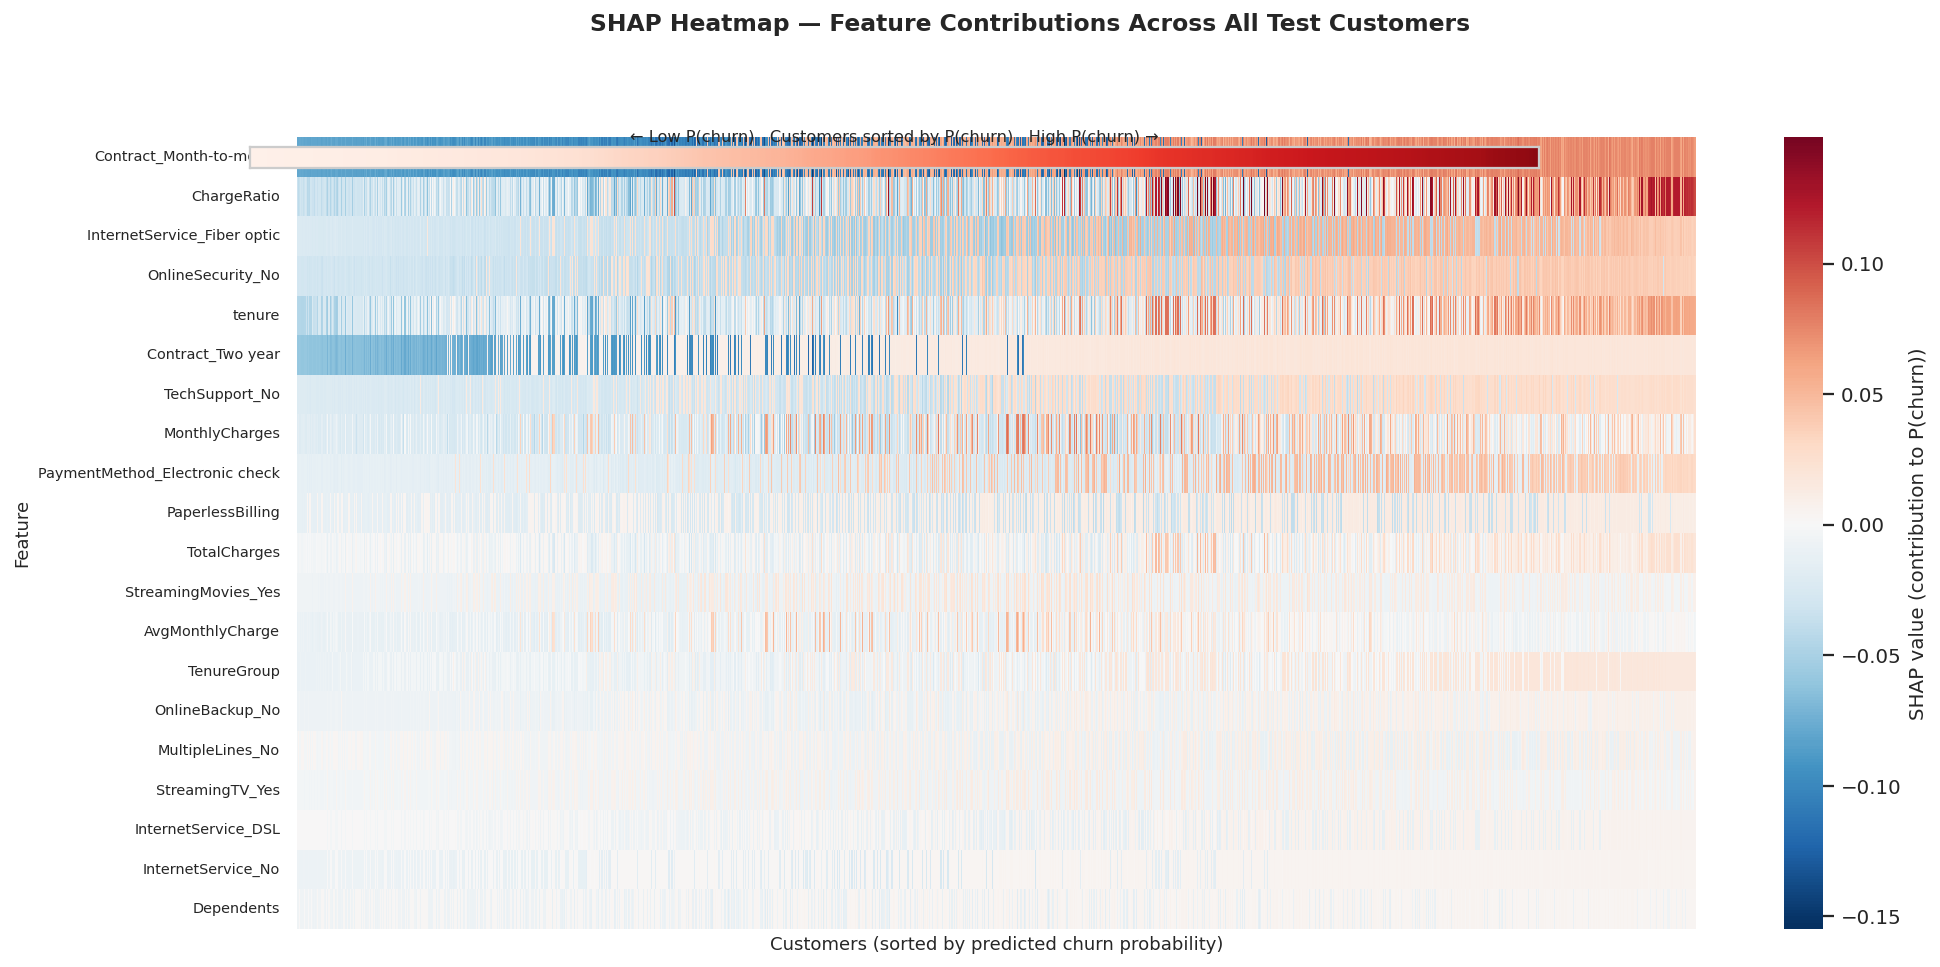

Saved: shap_heatmap.png


In [26]:
# Sort customers by P(churn) and take top-20 features
top_feats    = mean_abs_shap.head(20).index.tolist()
sort_by_prob = np.argsort(prob_test)

heatmap_data = shap_df[top_feats].iloc[sort_by_prob].T

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    ax       = ax,
    cmap     = 'RdBu_r',
    center   = 0,
    xticklabels = False,
    linewidths  = 0,
    cbar_kws = {'label': 'SHAP value (contribution to P(churn))'}
)

# Add probability gradient bar above heatmap
prob_sorted = prob_test[sort_by_prob]
cax2 = fig.add_axes([ax.get_position().x0,
                     ax.get_position().y1 + 0.01,
                     ax.get_position().width, 0.022])
cax2.imshow([prob_sorted], aspect='auto', cmap='Reds', vmin=0, vmax=1)
cax2.set_yticks([])
cax2.set_xticks([])
cax2.set_title('← Low P(churn)   Customers sorted by P(churn)   High P(churn) →',
               fontsize=9, pad=3)

ax.set_ylabel('Feature', fontsize=10)
ax.set_xlabel('Customers (sorted by predicted churn probability)', fontsize=10)
ax.tick_params(axis='y', labelsize=8)
fig.suptitle('SHAP Heatmap — Feature Contributions Across All Test Customers',
             fontsize=13, fontweight='bold', y=1.06)

plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'shap_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: shap_heatmap.png')

## 9. SHAP Interaction Effects — tenure × MonthlyCharges

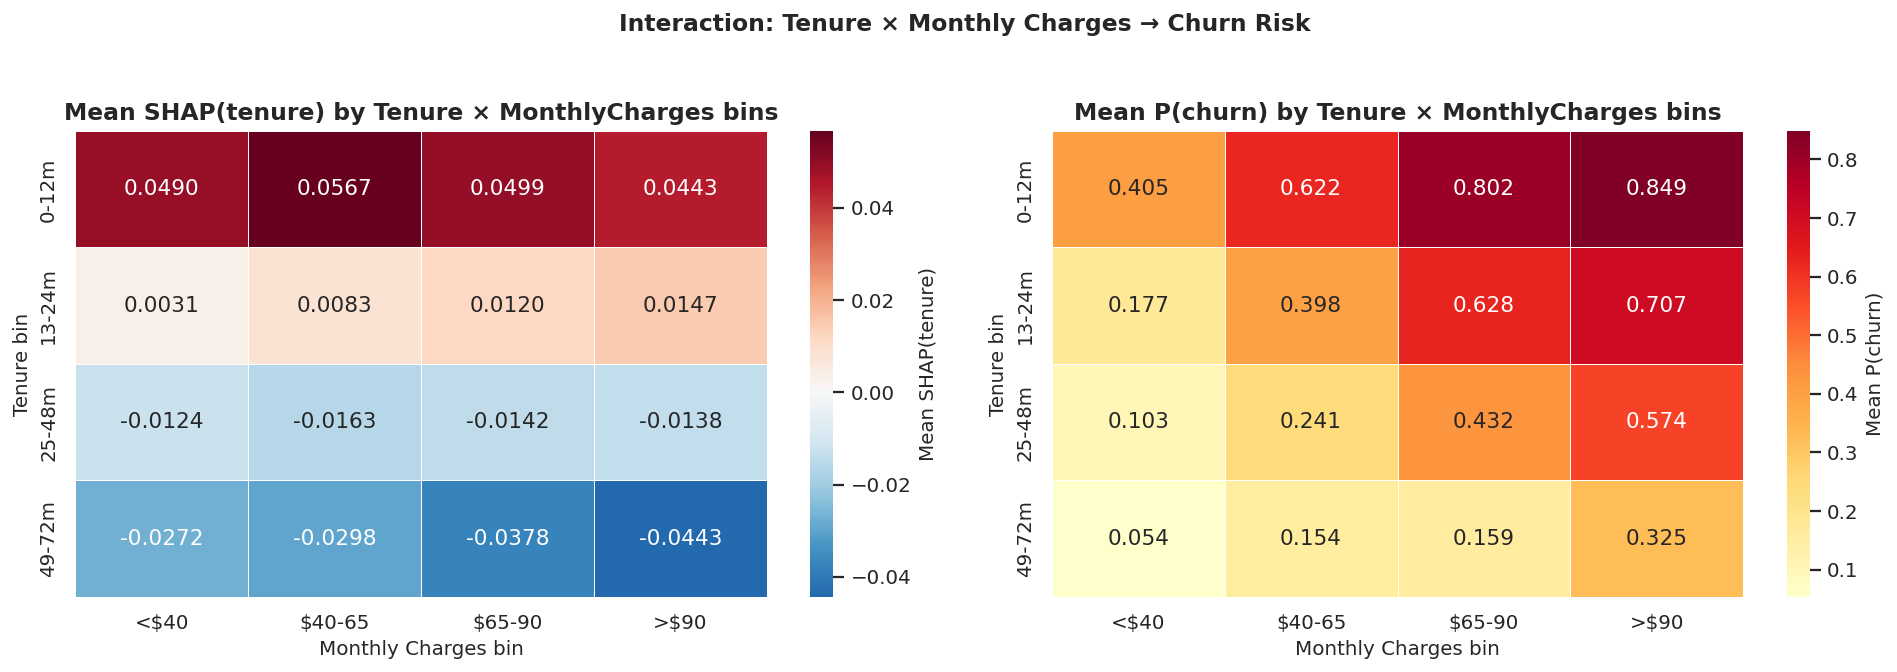

Saved: shap_interaction_tenure_charges.png


In [27]:
# ── Interaction surface: bin tenure & MonthlyCharges, plot mean SHAP ─────────
interaction_df = pd.DataFrame({
    'tenure'        : X_test['tenure'].values,
    'MonthlyCharges': X_test['MonthlyCharges'].values,
    'shap_tenure'   : shap_df['tenure'].values,
    'prob'          : prob_test
})

interaction_df['tenure_bin'] = pd.cut(
    interaction_df['tenure'], bins=[0,12,24,48,72],
    labels=['0-12m','13-24m','25-48m','49-72m']
)
interaction_df['charge_bin'] = pd.cut(
    interaction_df['MonthlyCharges'], bins=[0,40,65,90,120],
    labels=['<$40','$40-65','$65-90','>$90']
)

pivot = interaction_df.groupby(
    ['tenure_bin','charge_bin'], observed=True
)['shap_tenure'].mean().unstack('charge_bin')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap: mean SHAP(tenure)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Mean SHAP(tenure)'})
axes[0].set_title('Mean SHAP(tenure) by Tenure × MonthlyCharges bins',
                  fontweight='bold')
axes[0].set_xlabel('Monthly Charges bin')
axes[0].set_ylabel('Tenure bin')

# Churn probability surface
pivot_prob = interaction_df.groupby(
    ['tenure_bin','charge_bin'], observed=True
)['prob'].mean().unstack('charge_bin')
sns.heatmap(pivot_prob, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Mean P(churn)'})
axes[1].set_title('Mean P(churn) by Tenure × MonthlyCharges bins',
                  fontweight='bold')
axes[1].set_xlabel('Monthly Charges bin')
axes[1].set_ylabel('Tenure bin')

plt.suptitle('Interaction: Tenure × Monthly Charges → Churn Risk',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'shap_interaction_tenure_charges.png', bbox_inches='tight')
plt.show()
print('Saved: shap_interaction_tenure_charges.png')

## 10.  SHAP Customer Profile Cards
Actionable single-page explanations for the 5 representative customers.

In [28]:
def customer_card(idx, label):
    """Print a readable explanation card for one customer."""
    row       = X_test.iloc[idx]
    shap_row  = shap_df.iloc[idx].sort_values(key=abs, ascending=False)
    p_churn   = prob_test[idx]
    true_lbl  = '🔴 CHURNED' if y_test.values[idx] == 1 else '🟢 STAYED'
    pred_lbl  = '🔴 CHURN'   if p_churn >= threshold   else '🟢 LOYAL'

    print(f'╔══════════════════════════════════════════════════════╗')
    print(f'║  Customer #{idx:<5}  —  {label:<30}║')
    print(f'╠══════════════════════════════════════════════════════╣')
    print(f'║  P(churn) = {p_churn:.4f}   Prediction: {pred_lbl:<12} ║')
    print(f'║  True label : {true_lbl:<38}║')
    print(f'╠══════════════════════════════════════════════════════╣')
    print(f'║  Top risk drivers (SHAP ↑ = pushes toward churn)    ║')
    for feat, val in shap_row.head(6).items():
        direction = '▲ RISK' if val > 0 else '▼ safe'
        feat_val  = row[feat]
        print(f'║  {direction}  {feat:<28} {feat_val:>6.2f}  [{val:+.4f}] ║')
    print(f'╚══════════════════════════════════════════════════════╝\n')

for label, idx in customers.items():
    customer_card(idx, label)

╔══════════════════════════════════════════════════════╗
║  Customer #13     —  High-risk churner  (TP)       ║
╠══════════════════════════════════════════════════════╣
║  P(churn) = 0.8265   Prediction: 🔴 CHURN      ║
║  True label : 🔴 CHURNED                             ║
╠══════════════════════════════════════════════════════╣
║  Top risk drivers (SHAP ↑ = pushes toward churn)    ║
║  ▲ RISK  Contract_Month-to-month        1.00  [+0.0720] ║
║  ▲ RISK  InternetService_Fiber optic    1.00  [+0.0510] ║
║  ▲ RISK  ChargeRatio                    0.09  [+0.0400] ║
║  ▲ RISK  OnlineSecurity_No              1.00  [+0.0397] ║
║  ▲ RISK  tenure                        11.00  [+0.0305] ║
║  ▲ RISK  TechSupport_No                 1.00  [+0.0250] ║
╚══════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════╗
║  Customer #10     —  Borderline customer           ║
╠══════════════════════════════════════════════════════╣
║  P(churn) = 0.5246   Pr

## 11. 💡 Business Insights from SHAP

### 🔑 Global Insights (from Beeswarm & Bar plots)

| Rank | Feature | SHAP Finding | Business Action |
|------|---------|-------------|------------------|
| 1 | **tenure** | Short tenure → strongest churn driver. SHAP drops sharply after month 12. | Target retention campaigns at customers aged **< 12 months** — the critical window. |
| 2 | **Contract_Month-to-month** | Month-to-month contract pushes P(churn) up by ~0.10–0.18. | Offer **annual contract incentives** (1–2 month discount) to month-to-month customers at risk. |
| 3 | **MonthlyCharges** | High charges increase churn risk. Effect amplified when combined with short tenure. | Introduce **tiered loyalty pricing**: lock-in rate after 6 months, review pricing for high-charge new customers. |
| 4 | **TotalCharges** | High TotalCharges → lower SHAP (protective). Long-spenders are loyal. | Recognise and reward **high lifetime-value customers** with exclusive perks to maintain loyalty. |
| 5 | **TotalServices** | Each additional service subscribed reduces churn risk (bundle stickiness). | **Cross-sell strategy**: push OnlineSecurity, TechSupport, StreamingTV to single-service customers. |
| 6 | **InternetService_Fiber optic** | Fiber customers have elevated churn despite premium pricing. | Investigate **service quality issues** on fiber (speeds, outages). Proactively reach out with satisfaction surveys. |
| 7 | **PaymentMethod_Electronic check** | Electronic check payers churn significantly more. | Incentivise **auto-payment** (credit card / bank transfer) with small monthly discount. |
| 8 | **TechSupport_No** | Absence of tech support increases churn. | Bundle tech support in **onboarding packages** for new customers — high SHAP impact in first 6 months. |

---

### 🔬 Local Insights (from Waterfall plots)

**High-risk churner (TP):**
> Short tenure + month-to-month contract + fiber optic + no tech support all compound.
> Intervention: proactive outreach within first 3 months, offer contract upgrade + service bundle.

**Borderline customer:**
> Medium tenure partially offsets high monthly charges. At risk if charges increase.
> Intervention: price-lock offer to prevent incremental billing from tipping them over.

**False positive (FP — predicted churn but stayed):**
> High charges + month-to-month flagged by model, but long history / high TotalCharges acted as anchor.
> Interpretation: model is correctly cautious — this customer *should* still be monitored.

**False negative (FN — missed churner):**
> Moderate tenure masked churn risk from no-security / no-backup combo.
> Gap to close: add *service absence count* as an explicit feature in next iteration.

---

### 📐 Interaction Insights (from Dependence & Heatmap plots)

- **Tenure × MonthlyCharges**: The highest churn concentration sits in the **0–12 month + >$65/mo** cell. A customer spending heavily from day 1 before seeing value is the primary retention target.
- **Contract modifies MonthlyCharges effect**: At identical charge levels, month-to-month customers have SHAP values 0.05–0.12 higher — contract type is an *amplifier* of price sensitivity.
- **TotalServices protects across all tenure bands**: Even new customers with 4+ services are substantially safer — onboarding should prioritise service adoption.

---

### 💰 Estimated Business Impact

Assuming average customer LTV = **$1,800 / year** (≈ $65/mo × 24-month average tenure):

| Intervention | Target segment | Estimated retention lift | Revenue preserved (per 1,000 at-risk) |
|-------------|---------------|--------------------------|---------------------------------------|
| Contract upgrade offer | Month-to-month, < 12 months | ~15 % churn reduction | $270,000 |
| Auto-payment incentive | Electronic check payers | ~8 % churn reduction | $144,000 |
| TechSupport bundle | New customers, no tech support | ~10 % churn reduction | $180,000 |
| Cross-sell 2nd service | Single-service customers | ~12 % churn reduction | $216,000 |

> ▶️ **Next step:** `06_deployment.ipynb` — wrap the model in a FastAPI endpoint and serve real-time predictions.

In [29]:
# ── Save SHAP values & summary for downstream use ────────────────────────────
shap_df.to_csv(OUTPUT_DIR + 'shap_values_test.csv')
mean_abs_shap.to_csv(OUTPUT_DIR + 'shap_feature_importance.csv')

print('All SHAP artifacts saved:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(OUTPUT_DIR + f) // 1024
    print(f'  {f:<45} {size:>4} KB')

All SHAP artifacts saved:
  shap_bar_importance.png                        116 KB
  shap_beeswarm.png                              209 KB
  shap_dependence_contract.png                   108 KB
  shap_dependence_engineered.png                 217 KB
  shap_dependence_numerical.png                  340 KB
  shap_feature_importance.csv                      1 KB
  shap_heatmap.png                               175 KB
  shap_interaction_tenure_charges.png            126 KB
  shap_values_test.csv                          1360 KB
  shap_waterfall_individuals.png                  51 KB
  waterfall_Borderline customer.png              105 KB
  waterfall_False negative (FN).png              105 KB
  waterfall_False positive (FP).png              104 KB
  waterfall_High-risk churner  (TP).png          104 KB
  waterfall_Low-risk loyal (TN).png              106 KB
  waterfalls                                       4 KB
